In [1]:
import pandas as pd
import os

# Caminho onde você salvou (conforme seu script anterior)
caminho_arquivo = "./data/raw/sim/sim/DOAC2020.parquet"

# O Pandas lê a PASTA inteira e entende o que tem dentro
df_sim = pd.read_parquet(caminho_arquivo)

print("Dados carregados do disco (sem internet):")
print(df_sim.head())

# --- AQUI ENTRA SUA LÓGICA DE LIMPEZA ---
# 1. Filtrar colunas inúteis
# 2. Criar flags (ex: Causa Violenta)
# 3. Salvar o resultado final na pasta 'processed'
df_sim.to_csv("./data/processed/sim_tratado_acre.csv", index=False)

Dados carregados do disco (sem internet):
  ORIGEM TIPOBITO   DTOBITO HORAOBITO NATURAL CODMUNNATU    DTNASC IDADE SEXO  \
0      1        2  18052020     1452      812    120010   07061932   487    1   
1      1        2  20052020     2115      812    120010   16031952   468    2   
2      1        2  21052020     1200      812    120010   17021961   459    2   
3      1        2  21052020     1233      812    120010   10081942   477    2   
4      1        2  22052020     0730      812    120030   13041936   484    2   

  RACACOR  ...  FONTES TPRESGINFO TPNIVELINV NUDIASINF  DTCADINF MORTEPARTO  \
0       4  ...                                                                
1       4  ...                                                                
2       4  ...                                                                
3       4  ...                                                                
4       4  ...                                                              

Agora quero uma descrição detalhada das colunas:

In [4]:
variaveis_sim = [
    "TIPOBITO",   # 1=Fetal, 2=Não Fetal (Essencial para filtrar natimortos)
    "DTOBITO",    # Data do Óbito (ddmmaaaa)
    "IDADE",      # Idade codificada (precisa da função de tratamento)
    "SEXO",       # M/F/I
    "RACACOR",    # 1=Branca, 2=Preta, 4=Parda...
    "ESC2010",    # Escolaridade Nível (Substitui o antigo 'ESC' que parou de ser usado)
    "CODMUNRES",  # Município de Residência (Sua chave principal)
    "CIRCOBITO",  # 1=Acidente, 2=Suicídio, 3=Homicídio (Validação de Causas Externas)
    "CAUSABAS"    # Causa Básica final (A 'DOENÇA' ou 'VIOLÊNCIA' real para o Cluster)
]

df_exemplo = df_sim[variaveis_sim]

In [6]:
summary = df_exemplo.describe(include='all')
print(summary)

       TIPOBITO   DTOBITO IDADE  SEXO RACACOR ESC2010 CODMUNRES CIRCOBITO  \
count      4860      4860  4860  4860    4860    4860      4860      4860   
unique        1       366   172     3       6       8        23         6   
top           2  22052020   467     1       4       1   120040              
freq       4860        31   105  3010    3347    1204      2611      4266   

       CAUSABAS  
count      4860  
unique      648  
top        B342  
freq        809  


/tmp/ipykernel_80139/787803056.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


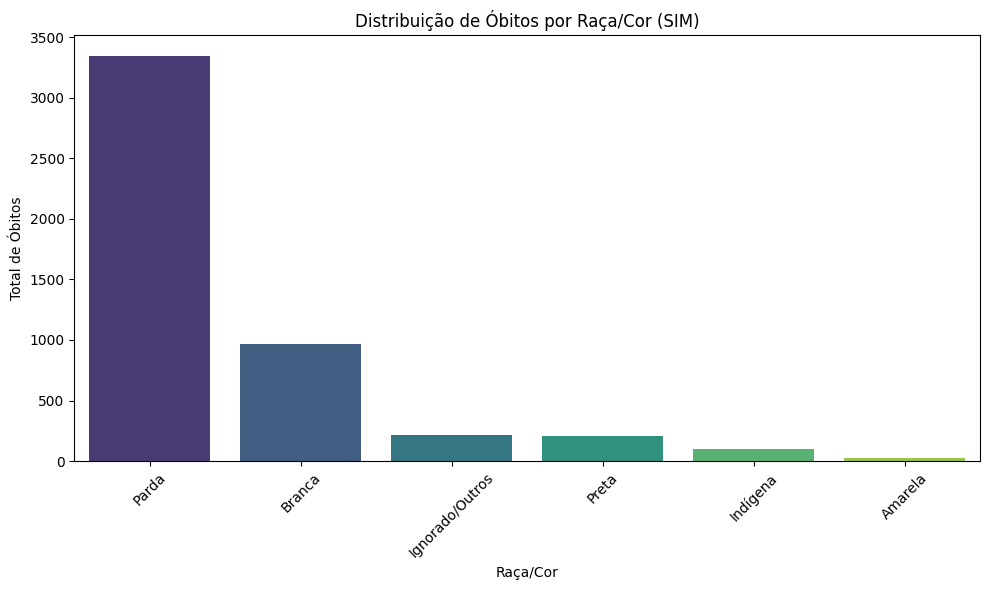

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dicionário de tradução conforme o PDF (Pág 1)
# 1-Branca; 2-Preta; 3-Amarela; 4-Parda; 5-Indígena
mapa_raca = {
    '1': 'Branca',
    '2': 'Preta',
    '3': 'Amarela',
    '4': 'Parda',
    '5': 'Indígena'
}

# 2. Criar uma cópia para não alterar seus dados originais (opcional)
df_plot = df_exemplo.copy()

# 3. Substituir os códigos pelos nomes
# O .astype(str) garante que o código seja lido como texto '1' e não número 1
df_plot['RACACOR_NOME'] = df_plot['RACACOR'].astype(str).map(mapa_raca)

# Se houver valores nulos ou fora do padrão, preenchemos com "Ignorado"
df_plot['RACACOR_NOME'] = df_plot['RACACOR_NOME'].fillna('Ignorado/Outros')

# 4. Plotar
plt.figure(figsize=(10, 6))

# order=... garante que as barras fiquem da maior para a menor
sns.countplot(
    data=df_plot, 
    x='RACACOR_NOME', 
    order=df_plot['RACACOR_NOME'].value_counts().index,
    palette='viridis' # Uma paleta de cores para diferenciar
)

plt.title('Distribuição de Óbitos por Raça/Cor (SIM)')
plt.xlabel('Raça/Cor')
plt.ylabel('Total de Óbitos')
plt.xticks(rotation=45) # Gira o texto se ficar muito grande
plt.tight_layout() # Ajusta as margens
plt.show()

Aparentemente funcionou. Agora precisamos testar com os dados de todo o Brasil. Vamos começar com o ano de 2020.